In [1]:
print("Welcome Backkkkk")

Welcome Backkkkk


In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
print("Import done baby")

Import done baby


In [3]:
#create a State for Quadratic Equation 
class QuadEqu(TypedDict):

    a : int
    b : int
    c : int

    # first output
    quadratic_equation : str

    # second output
    discriminant : float

    # there will be three different result which will be displayed based on the conditions
    result : str

In [4]:
graph = StateGraph(QuadEqu)

In [ ]:
def quadratic_equation(state : QuadEqu):
    
    equation = f'{state["a"]}x^2 + {state["b"]}x + {state["c"]}'

    # while returining the specific element from state instead of whole state you return it like this 
    return {'quadratic_equation' : equation}  # this is kindoff updating the equation in quadratic_equation

In [6]:
def calculate_discriminant(state : QuadEqu):
     discriminant = state["b"]**2 - (4 * state["a"] * state["c"])

     return {'discriminant': discriminant}

In [7]:
def real_roots(state : QuadEqu):
    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'the roots of the following equation are {root1} and {root2}'

    return {'result' : result}

In [8]:
def imaginary_roots(state : QuadEqu):
    root = (-state["b"]/(2*state["a"]))

    result = f'this equation has only one repeated root i.e {root}'

    return {'result': result}

    

In [9]:
def no_roots(state : QuadEqu):
    result = f'No roots for this equation'

    return {'result': result}

In [ ]:
#while using literals the elements in the list are nodes of the workflow not the functions
def check_condition(state : QuadEqu) -> Literal["Real_roots","Imaginary_roots","No_roots"]:

    if state['discriminant'] > 0:
        return "Real_roots"
    elif state['discriminant'] ==0:
        return "Imaginary_roots"
    else:
        return "No_roots"

    

In [11]:
# create and add nodes 

graph.add_node("Quadratic_Equation", quadratic_equation)
graph.add_node("Discriminant", calculate_discriminant)
graph.add_node("Real_roots", real_roots)
graph.add_node("Imaginary_roots",imaginary_roots)
graph.add_node("No_roots", no_roots)

In [ ]:
#create and add edges , we are adding conditional edges as well as we are outputting based on conditions
graph.add_edge(START,'Quadratic_Equation')
graph.add_edge('Quadratic_Equation','Discriminant')
# you can use function to join the nodes by using the conditional edges
graph.add_conditional_edges('Discriminant', check_condition)
graph.add_edge('Real_roots',END)
graph.add_edge('Imaginary_roots', END)
graph.add_edge('No_roots', END)

In [13]:
# compile the workflow
workflow = graph.compile()


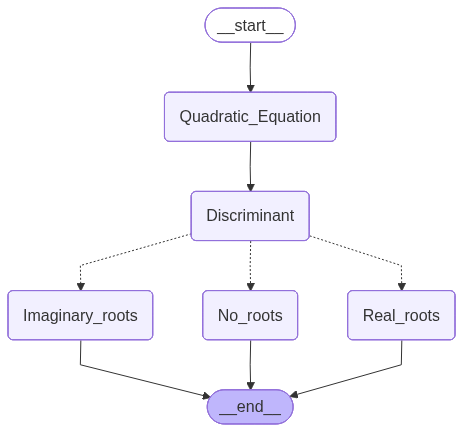

In [14]:
# Invoke the workflow 
workflow

In [15]:
# invoke the workflow 

input = {'a': 5, 'b': 4, 'c':4}
workflow.invoke(input)



{'a': 5,
 'b': 4,
 'c': 4,
 'quadratic_equation': '5x^2 + 4x + 4',
 'discriminant': -64,
 'result': 'No roots for this equation'}

In [ ]:
input = {'a': 1, 'b': -2, 'c': -3 }
workflow.invoke(input)

{'a': 1,
 'b': -2,
 'c': -3,
 'quadratic_equation': '1x^2 + -2x + -3',
 'discriminant': 16,
 'result': 'the roots of the following equation are 3.0 and -1.0'}

In [ ]:
# could be done this way as well
input = {'a': 1, 'b': -2, 'c': -3 }
output = workflow.invoke(input)
print(output)

{'a': 1, 'b': -2, 'c': -3, 'quadratic_equation': '1x^2 + -2x + -3', 'discriminant': 16, 'result': 'the roots of the following equation are 3.0 and -1.0'}
